In [1]:
!pip install -q mlflow
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"

# Reprendre la base MLflow et ses artefacts des séances précédentes
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

print("TensorFlow", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow 2.21.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from sklearn.impute import SimpleImputer

from aeroguard.donnees_ml import preparer_xy

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

# Médianes apprises sur le TRAIN uniquement
imputeur = SimpleImputer(strategy="median").fit(X_train)
Xa_train = imputeur.transform(X_train).astype("float32")
Xa_val = imputeur.transform(X_val).astype("float32")
ya_train = y_train.to_numpy().astype("float32")
ya_val = y_val.to_numpy().astype("float32")
infos_val = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]]

print("Train :", Xa_train.shape, "| Validation :", Xa_val.shape)
print("NaN restants :", int(np.isnan(Xa_train).sum()), "/", int(np.isnan(Xa_val).sum()))

Train : (3716, 126) | Validation : (819, 126)
NaN restants : 0 / 0


In [3]:
from aeroguard.reseaux import creer_normaliseur, creer_reseau_dense, nombre_parametres_entrainables

normaliseur = creer_normaliseur(Xa_train)
reseau = creer_reseau_dense(Xa_train.shape[1], normaliseur=normaliseur)

reseau.summary()
print("Paramètres entraînables :", nombre_parametres_entrainables(reseau))

Model: "aeroguard_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalisation (Normalization)   │ (None, 126)            │           253 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cachee_1 (Dense)                │ (None, 64)             │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cachee_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proba_usure (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,494 (41.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 253 (1016.00 B)

Paramètres entraînables : 10241


In [4]:
from sklearn.utils.class_weight import compute_class_weight

poids_classes = dict(enumerate(
    compute_class_weight("balanced", classes=np.array([0, 1]), y=ya_train.astype(int))
))
print("Poids des classes :", {classe: round(poids, 2) for classe, poids in poids_classes.items()})

EPOQUES = 60
TAILLE_LOT = 64

historique = reseau.fit(
    Xa_train, ya_train,
    validation_data=(Xa_val, ya_val),
    epochs=EPOQUES,
    batch_size=TAILLE_LOT,
    class_weight=poids_classes,
    verbose=0,
)

courbes = pd.DataFrame(historique.history)
courbes.index += 1
courbes.iloc[[0, 9, 29, 59]].round(3)

Poids des classes : {0: np.float64(1.7), 1: np.float64(0.71)}


,loss,pr_auc,val_loss,val_pr_auc
1,0.503,0.933,0.445,0.955
10,0.215,0.988,0.304,0.974
30,0.132,0.995,0.311,0.976
60,0.083,0.998,0.378,0.968


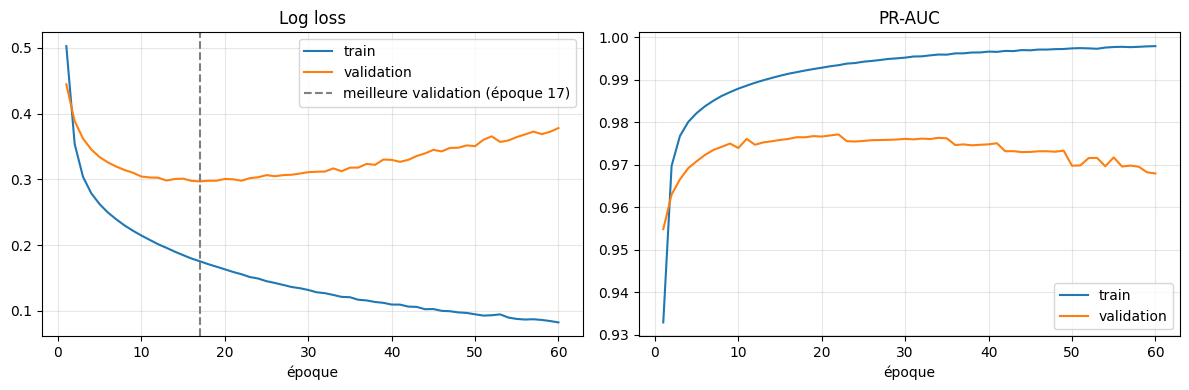

Perte de validation minimale à l'époque 17 : 0.297 (finale : 0.378)


In [5]:
meilleure_epoque = int(courbes["val_loss"].idxmin())

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(courbes.index, courbes["loss"], label="train")
axes[0].plot(courbes.index, courbes["val_loss"], label="validation")
axes[0].axvline(meilleure_epoque, color="gray", linestyle="--",
                label=f"meilleure validation (époque {meilleure_epoque})")
axes[0].set_title("Log loss")
axes[1].plot(courbes.index, courbes["pr_auc"], label="train")
axes[1].plot(courbes.index, courbes["val_pr_auc"], label="validation")
axes[1].set_title("PR-AUC")
for axe in axes:
    axe.set_xlabel("époque")
    axe.legend()
    axe.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/43_courbes_reseau_dense.png", dpi=150)
plt.show()

print(f"Perte de validation minimale à l'époque {meilleure_epoque} : "
      f"{courbes['val_loss'].min():.3f} (finale : {courbes['val_loss'].iloc[-1]:.3f})")

In [6]:
from aeroguard.metier import evaluer_alerte
from aeroguard.modeles import seuil_optimal

probas_reseau = reseau.predict(Xa_val, verbose=0).ravel()
seuil_reseau, f1_au_seuil = seuil_optimal(ya_val.astype(int), probas_reseau)

scores_reseau = evaluer_alerte(
    y_val, probas_reseau, seuil_reseau, infos_val, k=3, col_moteur="moteur",
)

for cle in ["f1_macro", "pr_auc", "precision", "rappel", "moteurs_detectes",
            "avance_moyenne", "fausses_alarmes_total", "moteurs_avec_fausse_alarme"]:
    print(f"{cle:28s} {scores_reseau[cle]:.3f}")
print(f"{'seuil':28s} {seuil_reseau:.2f}")

f1_macro                     0.872
pr_auc                       0.981
precision                    0.946
rappel                       0.892
moteurs_detectes             11.000
avance_moyenne               43.364
fausses_alarmes_total        2.000
moteurs_avec_fausse_alarme   1.000
seuil                        0.69


In [7]:
import math

CHEMIN_MODELE = f"{DOSSIER}/models/reseau_dense_v4.keras"
reseau.save(CHEMIN_MODELE)


def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


mlflow.set_experiment("aeroguard-alerte")
with mlflow.start_run(run_name="reseau_dense_alerte") as run:
    mlflow.log_params({
        "modele": "reseau_dense",
        "architecture": "126-64-32-1",
        "activation": "relu",
        "optimiseur": "adam",
        "taux_apprentissage": 1e-3,
        "epoques": EPOQUES,
        "taille_lot": TAILLE_LOT,
        "ponderation": "balanced",
        "imputation": "median",
        "normalisation": "keras_normalization",
        "parametres_entrainables": nombre_parametres_entrainables(reseau),
        "seuil": round(seuil_reseau, 2),
        "fenetre_confirmation": 3,
    })
    mlflow.log_metrics(scores_numeriques(scores_reseau))
    mlflow.log_metric("meilleure_epoque_validation", meilleure_epoque)
    mlflow.log_artifact(CHEMIN_MODELE)
    mlflow.log_artifact(f"{DOSSIER}/results/figures/43_courbes_reseau_dense.png")
    mlflow.set_tags({"tache": "alerte", "donnees": "N-CMAPSS", "lecon": "4.3", "jeu": "validation"})

print("✅ Run enregistré :", run.info.run_id[:8])

2026/10/07 11:25:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/07 11:25:12 INFO mlflow.store.db.utils: Updating database tables


✅ Run enregistré : 811f615f


In [8]:
runs = mlflow.search_runs(
    experiment_names=["aeroguard-alerte"],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["start_time DESC"],
)
modeles_compares = ["xgboost_alerte", "logistique_alerte", "reseau_dense_alerte"]
leaderboard = (
    runs[runs["tags.mlflow.runName"].isin(modeles_compares)]
    .drop_duplicates("tags.mlflow.runName")          # le run le plus récent de chaque modèle
    .set_index("tags.mlflow.runName")
)
colonnes = ["params.seuil", "metrics.f1_macro", "metrics.pr_auc", "metrics.precision",
            "metrics.rappel", "metrics.moteurs_detectes", "metrics.avance_moyenne",
            "metrics.fausses_alarmes_total"]
leaderboard[colonnes].sort_values("metrics.f1_macro", ascending=False).round(3)

,params.seuil,metrics.f1_macro,metrics.pr_auc,metrics.precision,metrics.rappel,metrics.moteurs_detectes,metrics.avance_moyenne,metrics.fausses_alarmes_total
tags.mlflow.runName,,,,,,,,
logistique_alerte,0.37,0.894,0.987,0.955,0.913,11.0,45.182,2.0
xgboost_alerte,0.81,0.887,0.987,0.971,0.883,11.0,42.000,1.0
reseau_dense_alerte,0.69,0.872,0.981,0.946,0.892,11.0,43.364,2.0


In [9]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive


In [10]:
from sklearn.metrics import f1_score
from aeroguard.evaluation import appliquer_seuil


def tester_reseau(couches_cachees, graine):
    """Entraîne un réseau et renvoie son F1 macro au seuil optimal (validation)."""
    modele = creer_reseau_dense(Xa_train.shape[1], couches_cachees=couches_cachees,
                                normaliseur=creer_normaliseur(Xa_train), graine=graine)
    modele.fit(Xa_train, ya_train, epochs=EPOQUES, batch_size=TAILLE_LOT,
               class_weight=poids_classes, verbose=0)
    probas = modele.predict(Xa_val, verbose=0).ravel()
    seuil, f1 = seuil_optimal(ya_val.astype(int), probas)
    return {"couches": str(couches_cachees), "graine": graine,
            "parametres": nombre_parametres_entrainables(modele),
            "seuil": round(seuil, 2), "f1_macro": round(f1, 3)}


essais_graines = pd.DataFrame([tester_reseau((64, 32), graine) for graine in range(5)])
print("Exercice 5 — effet du hasard")
print(essais_graines)
print(f"F1 macro : moyenne {essais_graines['f1_macro'].mean():.3f}, "
      f"écart {essais_graines['f1_macro'].min():.3f} → {essais_graines['f1_macro'].max():.3f}\n")

essais_architectures = pd.DataFrame(
    [tester_reseau(couches, 42) for couches in [(16,), (64, 32), (128, 64)]]
)
print("Exercice 6 — taille du réseau")
print(essais_architectures)

Exercice 5 — effet du hasard
    couches  graine  parametres  seuil  f1_macro
0  (64, 32)       0       10241   0.61     0.872
1  (64, 32)       1       10241   0.47     0.882
2  (64, 32)       2       10241   0.39     0.880
3  (64, 32)       3       10241   0.85     0.888
4  (64, 32)       4       10241   0.92     0.868
F1 macro : moyenne 0.878, écart 0.868 → 0.888

Exercice 6 — taille du réseau
     couches  graine  parametres  seuil  f1_macro
0      (16,)      42        2049   0.60     0.859
1   (64, 32)      42       10241   0.69     0.872
2  (128, 64)      42       24577   0.64     0.879
